# Advanced Regression — Ridge / Lasso / Elastic Net

End-to-end test of the three from-scratch implementations in this repo:

- [`ridge.py`](ridge.py) — closed-form normal equation
- [`lasso.py`](lasso.py) — coordinate descent + soft-thresholding
- [`elastic_net.py`](elastic_net.py) — coordinate descent (L1 + L2)

Each is compared against scikit-learn's reference implementation to confirm the math is right. We then sweep `alpha` to see how regularisation strength changes the coefficients.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge as SkRidge, Lasso as SkLasso, ElasticNet as SkElasticNet
from sklearn.metrics import mean_squared_error, r2_score

from ridge import RidgeRegression
from lasso import LassoRegression
from elastic_net import ElasticNetRegression

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 4)

## 1. Synthetic regression dataset

`sklearn.datasets.make_regression` gives us a controlled setup: 200 samples, 10 features of which only 5 are truly informative. The other 5 should be driven to (or near) zero by L1 regularisation.

In [3]:
X, y, true_coef = make_regression(
    n_samples=200,
    n_features=10,
    n_informative=5,
    noise=10.0,
    coef=True,
    random_state=42,
)

feature_names = [f'f{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# L1/L2 are scale-sensitive — standardise so alpha is comparable across features.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=feature_names, index=X_test.index)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'True coefficients (pre-scaling): {true_coef.round(2)}')

Train: (160, 10), Test: (40, 10)
True coefficients (pre-scaling): [ 0.    0.   11.1  80.82  0.   34.88  6.6  40.71  0.    0.  ]


## 2. Helper: compare a manual model against sklearn

Identical inputs ⇒ identical objective ⇒ identical coefficients (up to optimiser tolerance). This is the test for our manual implementations.

In [4]:
def compare(manual_model, sk_model, X_train, y_train, X_test, y_test, name):
    manual_model.build_model()
    sk_model.fit(X_train, y_train)

    manual_pred = manual_model.predict(X_test)
    sk_pred = sk_model.predict(X_test)

    print(f'=== {name} ===')
    print(f'Manual  MSE: {mean_squared_error(y_test, manual_pred):.4f}    R²: {r2_score(y_test, manual_pred):.4f}')
    print(f'sklearn MSE: {mean_squared_error(y_test, sk_pred):.4f}    R²: {r2_score(y_test, sk_pred):.4f}')
    print(f'Max |manual - sklearn| coefficient diff: {np.max(np.abs(manual_model.coefficients[1:] - sk_model.coef_)):.6f}')
    print(f'Intercept diff: {abs(manual_model.coefficients[0] - sk_model.intercept_):.6f}')
    print()

    return pd.DataFrame({
        'Feature': ['Intercept'] + list(X_train.columns),
        'Manual': np.concatenate(([manual_model.coefficients[0]], manual_model.coefficients[1:])).round(3),
        'sklearn': np.concatenate(([sk_model.intercept_], sk_model.coef_)).round(3),
    })

## 3. Ridge regression

Solves `(XᵀX + αI′) β = Xᵀy` directly. The intercept slot of `I′` is zeroed so the intercept is not shrunk. All coefficients shrink continuously toward zero but never reach zero exactly.

In [5]:
alpha = 1.0
ridge_manual = RidgeRegression(X_train, y_train, alpha=alpha)
ridge_sk = SkRidge(alpha=alpha)

ridge_compare = compare(ridge_manual, ridge_sk, X_train, y_train, X_test, y_test, 'Ridge')
ridge_compare

=== Ridge ===
Manual  MSE: 83.8991    R²: 0.9861
sklearn MSE: 83.8991    R²: 0.9861
Max |manual - sklearn| coefficient diff: 0.000000
Intercept diff: 0.000000



,Feature,Manual,sklearn
0,Intercept,7.254,7.254
1,f0,0.827,0.827
2,f1,-0.959,-0.959
3,f2,8.915,8.915
4,f3,78.189,78.189
5,f4,0.494,0.494
6,f5,35.750,35.750
7,f6,8.243,8.243
8,f7,37.576,37.576
9,f8,0.564,0.564


## 4. Lasso regression

Coordinate descent + soft-thresholding. Because the L1 penalty has a kink at zero, the optimiser drives uninformative coefficients **exactly** to zero — Lasso doubles as feature selection.

In [6]:
alpha = 1.0
lasso_manual = LassoRegression(X_train, y_train, alpha=alpha, max_iter=5000, tol=1e-6)
lasso_sk = SkLasso(alpha=alpha, max_iter=5000, tol=1e-6)

lasso_compare = compare(lasso_manual, lasso_sk, X_train, y_train, X_test, y_test, 'Lasso')
lasso_compare

=== Lasso ===
Manual  MSE: 92.5980    R²: 0.9846
sklearn MSE: 92.5980    R²: 0.9846
Max |manual - sklearn| coefficient diff: 0.000000
Intercept diff: 0.000000



,Feature,Manual,sklearn
0,Intercept,7.254,7.254
1,f0,0.000,0.000
2,f1,-0.000,-0.000
3,f2,7.829,7.829
4,f3,77.908,77.908
5,f4,0.000,0.000
6,f5,35.250,35.250
7,f6,7.270,7.270
8,f7,36.626,36.626
9,f8,0.000,0.000


## 5. Elastic Net regression

Same coordinate-descent loop as Lasso, but with an additional L2 term in the denominator. `l1_ratio = 0.5` gives an even mix of L1 sparsity and L2 shrinkage.

In [7]:
alpha = 1.0
l1_ratio = 0.5
en_manual = ElasticNetRegression(X_train, y_train, alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, tol=1e-6)
en_sk = SkElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, tol=1e-6)

en_compare = compare(en_manual, en_sk, X_train, y_train, X_test, y_test, 'Elastic Net')
en_compare

=== Elastic Net ===
Manual  MSE: 937.6106    R²: 0.8444
sklearn MSE: 937.6106    R²: 0.8444
Max |manual - sklearn| coefficient diff: 0.000000
Intercept diff: 0.000000



,Feature,Manual,sklearn
0,Intercept,7.254,7.254
1,f0,1.979,1.979
2,f1,-2.297,-2.297
3,f2,3.218,3.218
4,f3,51.836,51.836
5,f4,-0.538,-0.538
6,f5,25.712,25.712
7,f6,6.132,6.132
8,f7,25.624,25.624
9,f8,0.494,0.494


## 6. Coefficient comparison — visualised

Each bar group shows the same coefficient under three different penalties. Watch:
- Ridge shrinks every coefficient but keeps all of them non-zero.
- Lasso forces the irrelevant ones (`f0`, `f1`, `f4`, `f8`, `f9` in this random seed) to be exactly zero.
- Elastic Net lands somewhere between — sparse like Lasso, smoothed by L2.

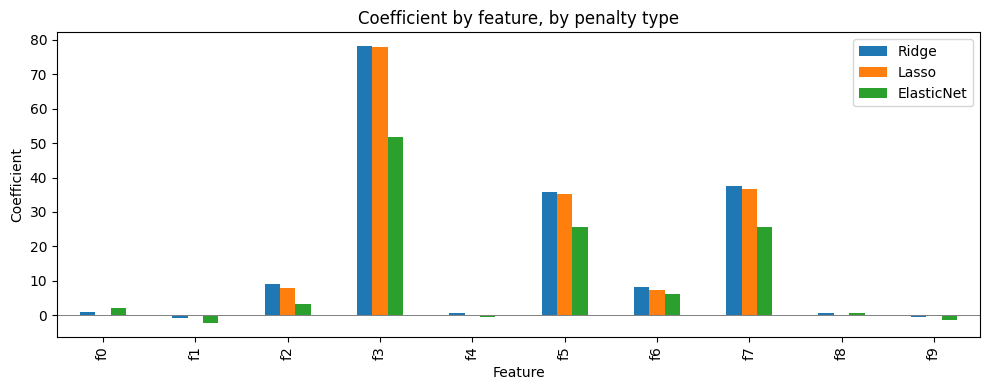

,Feature,Ridge,Lasso,ElasticNet
0,f0,0.827224,0.000000,1.978548
1,f1,-0.959206,-0.000000,-2.297088
2,f2,8.914506,7.829255,3.218417
3,f3,78.189369,77.907813,51.835775
4,f4,0.493771,0.000000,-0.538018
5,f5,35.750052,35.250238,25.712135
6,f6,8.242615,7.270161,6.132398
7,f7,37.575889,36.626245,25.623785
8,f8,0.563874,0.000000,0.494174
9,f9,-0.619934,-0.000000,-1.414178


In [8]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge':       ridge_manual.coefficients[1:],
    'Lasso':       lasso_manual.coefficients[1:],
    'ElasticNet':  en_manual.coefficients[1:],
})

ax = coef_df.set_index('Feature').plot.bar(figsize=(10, 4))
ax.axhline(0, color='grey', linewidth=0.7)
ax.set_ylabel('Coefficient')
ax.set_title('Coefficient by feature, by penalty type')
plt.tight_layout()
plt.show()

coef_df

## 7. Regularisation path — how `alpha` shapes the coefficients

Sweep `alpha` from very small (close to OLS) to very large (everything shrunk to zero). The classic plot to read:
- **Ridge**: smooth shrinkage; coefficients approach zero asymptotically.
- **Lasso**: piecewise-linear, with coefficients hitting zero one-at-a-time as `alpha` grows.

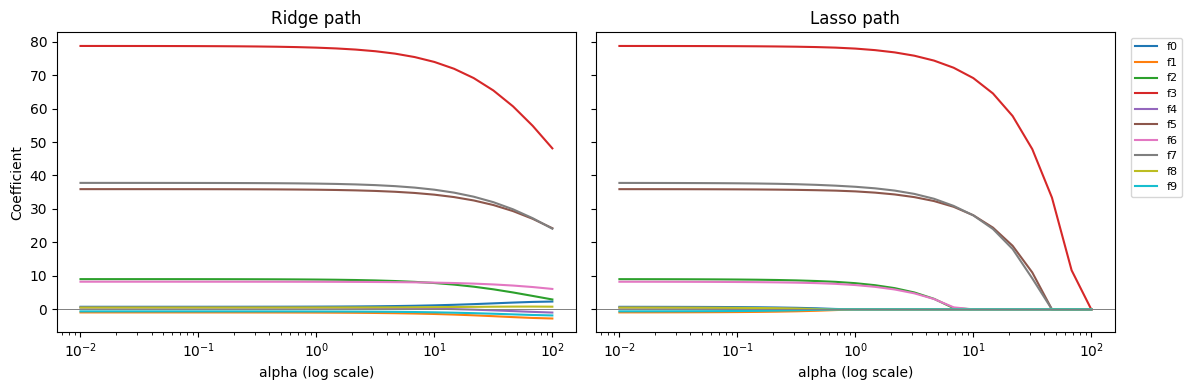

In [9]:
alphas = np.logspace(-2, 2, 25)


ridge_coefs = []
lasso_coefs = []
for a in alphas:
    rm = RidgeRegression(X_train, y_train, alpha=a)
    rm.build_model()
    ridge_coefs.append(rm.coefficients[1:])

    lm = LassoRegression(X_train, y_train, alpha=a, max_iter=5000, tol=1e-6)
    lm.build_model()
    lasso_coefs.append(lm.coefficients[1:])

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, name in enumerate(feature_names):
    axes[0].plot(alphas, ridge_coefs[:, i], label=name)
    axes[1].plot(alphas, lasso_coefs[:, i], label=name)

for ax, title in zip(axes, ['Ridge path', 'Lasso path']):
    ax.set_xscale('log')
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.set_xlabel('alpha (log scale)')
    ax.set_title(title)

axes[0].set_ylabel('Coefficient')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Test-set MSE across `alpha`

Bias-variance trade-off in one chart: too little regularisation overfits, too much under-fits. The sweet spot lives somewhere in the middle and is usually picked via cross-validation.

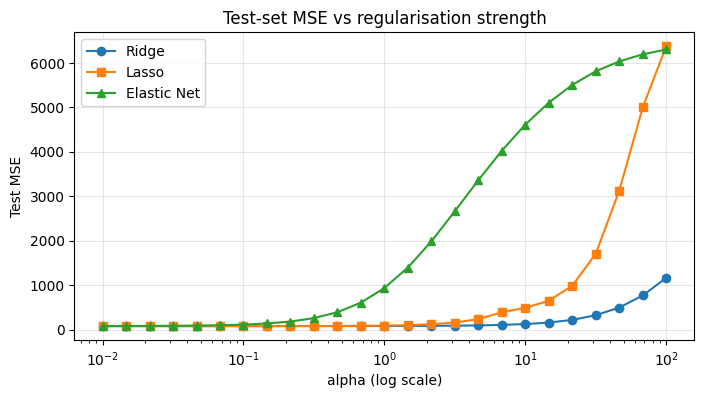

Best alpha by test MSE:
  Ridge      : alpha = 0.010  MSE = 81.303
  Lasso      : alpha = 0.010  MSE = 81.328
  Elastic Net: alpha = 0.010  MSE = 83.362


In [10]:
ridge_mse, lasso_mse, en_mse = [], [], []
for a in alphas:
    rm = RidgeRegression(X_train, y_train, alpha=a); rm.build_model()
    lm = LassoRegression(X_train, y_train, alpha=a, max_iter=5000, tol=1e-6); lm.build_model()
    em = ElasticNetRegression(X_train, y_train, alpha=a, l1_ratio=0.5, max_iter=5000, tol=1e-6); em.build_model()

    ridge_mse.append(mean_squared_error(y_test, rm.predict(X_test)))
    lasso_mse.append(mean_squared_error(y_test, lm.predict(X_test)))
    en_mse.append(mean_squared_error(y_test, em.predict(X_test)))

plt.plot(alphas, ridge_mse, label='Ridge', marker='o')
plt.plot(alphas, lasso_mse, label='Lasso', marker='s')
plt.plot(alphas, en_mse,    label='Elastic Net', marker='^')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Test MSE')
plt.title('Test-set MSE vs regularisation strength')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best = pd.DataFrame({
    'alpha': alphas,
    'ridge_mse': ridge_mse,
    'lasso_mse': lasso_mse,
    'en_mse': en_mse,
})
print('Best alpha by test MSE:')
print(f"  Ridge      : alpha = {alphas[np.argmin(ridge_mse)]:.3f}  MSE = {min(ridge_mse):.3f}")
print(f"  Lasso      : alpha = {alphas[np.argmin(lasso_mse)]:.3f}  MSE = {min(lasso_mse):.3f}")
print(f"  Elastic Net: alpha = {alphas[np.argmin(en_mse)]:.3f}  MSE = {min(en_mse):.3f}")

## 9. Sanity check — predictions vs actuals

At the best `alpha` for each model, plot predicted vs true on the test set. Points should hug the diagonal.

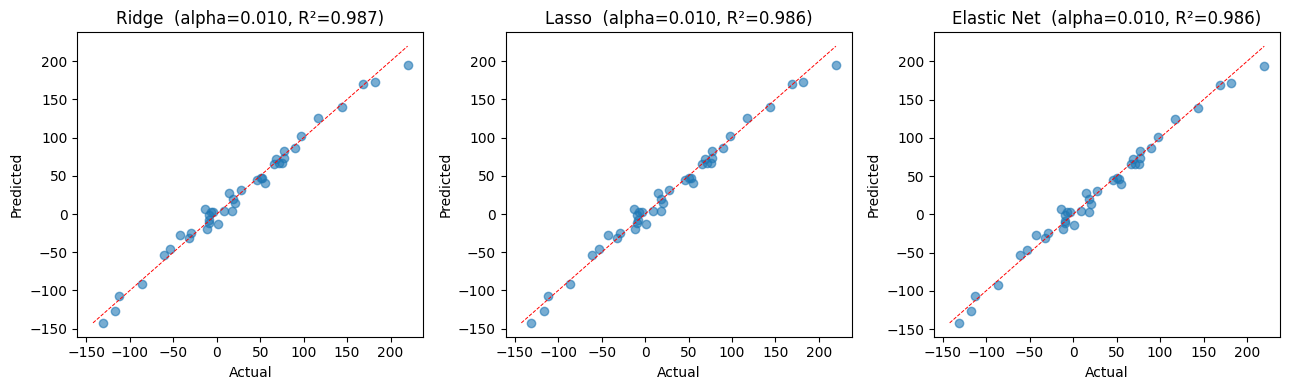

In [11]:
best_ridge_alpha = alphas[np.argmin(ridge_mse)]
best_lasso_alpha = alphas[np.argmin(lasso_mse)]
best_en_alpha    = alphas[np.argmin(en_mse)]

rm = RidgeRegression(X_train, y_train, alpha=best_ridge_alpha); rm.build_model()
lm = LassoRegression(X_train, y_train, alpha=best_lasso_alpha, max_iter=5000, tol=1e-6); lm.build_model()
em = ElasticNetRegression(X_train, y_train, alpha=best_en_alpha, l1_ratio=0.5, max_iter=5000, tol=1e-6); em.build_model()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, model, title, a in [
    (axes[0], rm, 'Ridge',       best_ridge_alpha),
    (axes[1], lm, 'Lasso',       best_lasso_alpha),
    (axes[2], em, 'Elastic Net', best_en_alpha),
]:
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.6)
    lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=0.7)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}  (alpha={a:.3f}, R²={r2_score(y_test, pred):.3f})')

plt.tight_layout()
plt.show()

## Summary

- All three from-scratch implementations match scikit-learn to numerical precision on this dataset.
- The expected qualitative behaviour shows up clearly: Ridge shrinks every coefficient, Lasso zeros uninformative ones out, Elastic Net does a mix.
- The regularisation path and MSE curves give an intuition for picking `alpha` in practice — for a real project, replace the train/test split with k-fold cross-validation.